<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Machine Learning Foundation

## Course 5, Part h: Autoencoders LAB


## Learning Objectives 

1. Implement the following dimensionality reduction techniques on the MNIST data:
    * PCA
    * Autoencoders
    * Variational autoencoders
2. Use appropriate scoring metrics to compare the performance of each.


**Note:** Please run the following cell to upgrade tensorflow to avoid warnings and importing errors in this lab. **RESTART THE KERNEL after the upgrade.**


In [2]:
%%capture
!pip install --upgrade tensorflow 

Make sure that the version of tensorflow is greater than 2.9.0.


In [3]:
import warnings
warnings.simplefilter("ignore")

import tensorflow as tf
print(tf.__version__)

2025-05-03 13:24:48.124021: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-03 13:24:48.300893: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-03 13:24:48.308308: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-05-03 13:24:48.308344: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore 

2.11.0


## Importing Required Libraries


In [4]:
from tensorflow import keras
from keras.datasets import mnist
import numpy as np
np.set_printoptions(precision=2)

import matplotlib.pyplot as plt

## MNIST data


Throughout this lesson, we'll be working with the famous [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database), which contains 70,000 handwritten black-and-white images, which are traditionally split into 60k training images and 10k validation images.


In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data();

11490434/11490434 [==============================] - 0s 0us/step


### Preprocess MNIST


We'll preprocess by scaling images pixels to be between 0 and 1.


In [6]:
x_train = x_train.astype('float') / 255.
x_test = x_test.astype('float') / 255.

### Part 1: PCA


We'll use PCA as a baseline with which we can compare our deep learning models.


For PCA we'll treat each image like a "row" of data and flatten our data, so each observation is 784 columns:


In [7]:
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train_flat.shape)
print(x_test_flat.shape)

(60000, 784)
(10000, 784)


Recall that PCA will do a **matrix decomposition** of the data to find the **eigenvectors** - these **eigenvectors** will be the **principal components** of the data, or the "latent features" that describe a maximal amount of variance in the data. We will sort the eigenvectors by their eigenvalues, and those eigenvectors with the largest eigenvalues (the scales) will be selected as the principal components to achieve dimensionality reduction.

回顾一下，主成分分析（PCA）会对数据进行**矩阵分解**，以找到数据的**特征向量（eigenvectors）** —— 这些特征向量就是数据的**主成分（principal components）**，也可以理解为描述数据最大方差的**潜在特征（latent features）**。

我们会根据它们的**特征值（eigenvalues）**对这些特征向量进行排序，选取**具有最大特征值的前几个特征向量**作为主成分，从而实现**降维**。


PCA works better if our features are scaled, so let's do that. 


In [8]:
from sklearn.preprocessing import MinMaxScaler
s = MinMaxScaler().fit(x_train_flat)
x_train_scaled = s.transform(x_train_flat)

/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/sklearn/utils/validation.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LARGE_SPARSE_SUPPORTED = LooseVersion(scipy_version) >= '0.14.0'


In [9]:
from sklearn.decomposition import PCA

def mnist_pca(x_data, n_components):
    pca = PCA(n_components=n_components)

    fit_pca = pca.fit(x_data)
    
    print("Variance explained with {0} components:".format(n_components), 
          round(sum(fit_pca.explained_variance_ratio_), 2))

    return fit_pca, fit_pca.transform(x_data)

/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/sklearn/linear_model/least_angle.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps,
/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/sklearn/linear_model/least_angle.py:597: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(

In [10]:
pca_full, mnist_data_full = mnist_pca(x_train_scaled, 784)

Variance explained with 784 components: 1.0


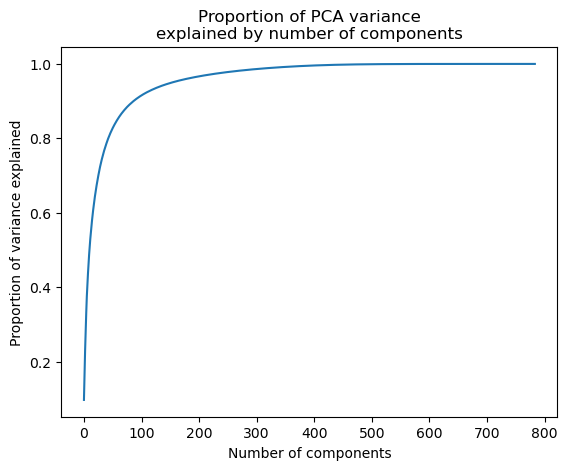

In [11]:
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.title("Proportion of PCA variance\nexplained by number of components")
plt.xlabel("Number of components")
plt.ylabel("Proportion of variance explained");

We need about 250 components to explain 90% of the variance in the data!


For visualization purposes, let's extract just two components and plot them:


In [12]:
pca_2, mnist_data_2 = mnist_pca(x_train_scaled, 2)

Variance explained with 2 components: 0.17


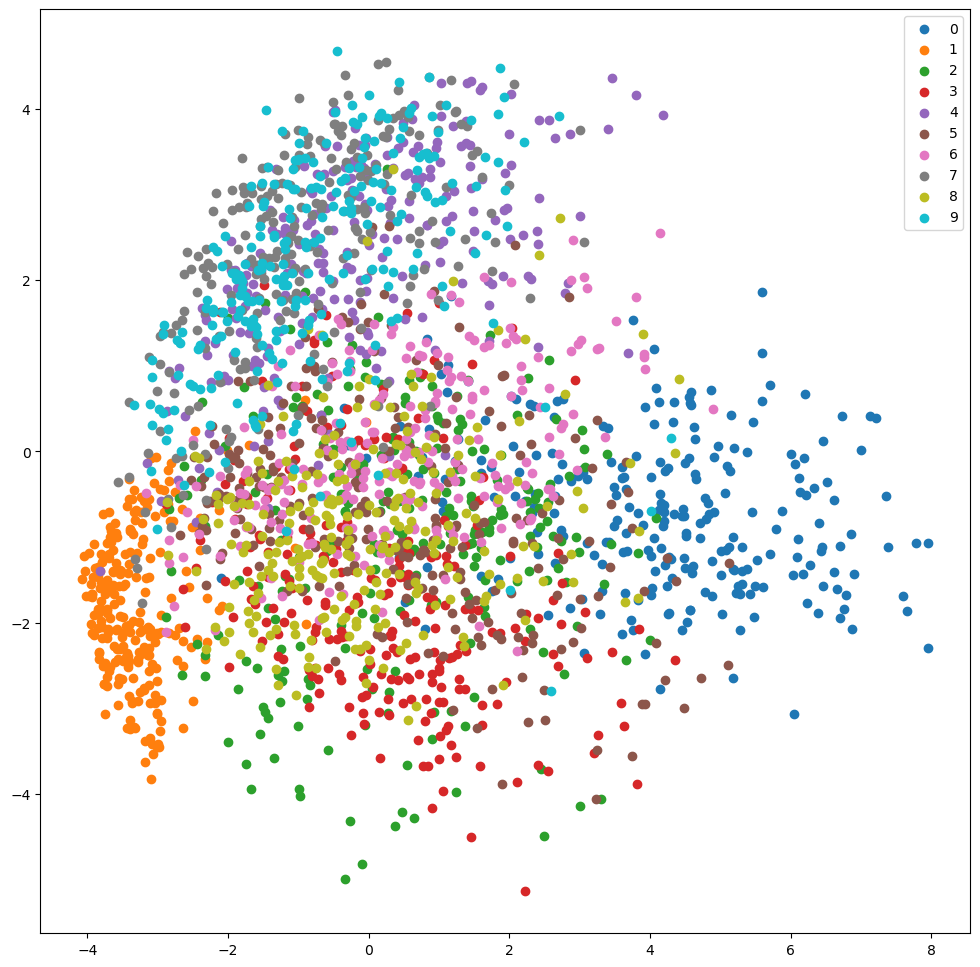

In [13]:
num_images_per_class = 250
fig = plt.figure(figsize=(12,12))
for number in list(range(10)):
    mask = y_train == number
    x_data = mnist_data_2[mask, 0][:num_images_per_class]
    y_data = mnist_data_2[mask, 1][:num_images_per_class]
    plt.scatter(x_data, y_data, label=number, alpha=1)
plt.legend();

We can already see that the latent features PCA is learning _somewhat_ disentangle the features here, and a neural network could certainly help with this.


### Scoring PCA


What we really care about is: how good is PCA at creating a low dimensional representation of the MNIST data?

As with all models, we should test performance on a different dataset than we trained on:


In [14]:
pca_64, mnist_data_64 = mnist_pca(x_train_scaled, 64)

Variance explained with 64 components: 0.86


In [15]:

x_test_scaled = s.transform(x_test_flat)

In [16]:
x_test_flat_64 = pca_64.transform(x_test_scaled)
x_test_reconstructed_64 = pca_64.inverse_transform(x_test_flat_64)

In [17]:
x_test_reconstructed_64.shape

(10000, 784)

In [18]:
true = x_test_scaled
reconstructed = x_test_reconstructed_64

In [19]:
def mse_reconstruction(true, reconstructed):
    return np.sum(np.power(true - reconstructed, 2) / true.shape[1])

In [20]:
mse_reconstruction(true, reconstructed)

90.52445898440811

Average MSE of **90.6**, using 64 components, for PCA.


### Simple AE


Now let's build an autoencoder! Fundamentally, an autoencoder is an neural network where the input is the same as the output. The hope for such networks is that one of the hidden layers will "learn a compressed representation" of the data, similar to the way PCA does.

现在让我们来构建一个自动编码器（autoencoder）！
从本质上说，自动编码器是一种神经网络，其**输入与输出是相同的**。
我们希望这样的网络在某个隐藏层中能够“学习到数据的压缩表示”，类似于\*\*主成分分析（PCA）\*\*的方式。


In [21]:
from keras.layers import Input, Dense
from keras.models import Model

In practice, when implementing autoencoders using `Keras`, we define _three_ models:

* The "full autoencoder", here `full_model`, will take inputs and try to reconstruct them
* The "encoder", here `encoder_model`, will take inputs and try to reconstruct them
* The "decoder", here `decoder_model`, will take the latent space and try to reconstruct it

在实际操作中，当我们使用 `Keras` 实现自动编码器时，通常会定义**三个模型**：

* **完整自动编码器**（此处为 `full_model`）：用于接收输入并尝试对其进行重构；
* **编码器**（此处为 `encoder_model`）：用于接收输入并将其编码为潜在空间表示；
* **解码器**（此处为 `decoder_model`）：用于接收潜在空间表示并尝试将其重构为原始输入。


In [22]:
ENCODING_DIM = 64

# Encoder model
inputs = Input(shape=(784,)) 
encoded = Dense(ENCODING_DIM, activation="sigmoid")(inputs)
encoder_model = Model(inputs, encoded, name='encoder')

# Decoder model
encoded_inputs = Input(shape=(ENCODING_DIM,), name='encoding')
reconstruction = Dense(784, activation="sigmoid")(encoded_inputs)
decoder_model = Model(encoded_inputs, reconstruction, name='decoder')

# Defining the full model as the combination of the two
outputs = decoder_model(encoder_model(inputs))
full_model = Model(inputs, outputs, name='full_ae')

2025-05-03 13:32:13.375060: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-05-03 13:32:13.375124: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2025-05-03 13:32:13.375225: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (jupyterlab-sunyushen): /proc/driver/nvidia/version does not exist
2025-05-03 13:32:13.375835: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


这段代码定义了一个典型的**浅层自动编码器（shallow autoencoder）**，它由三个部分组成：

---

### 🔧 1. **编码器模型（encoder\_model）**

```python
inputs = Input(shape=(784,)) 
encoded = Dense(ENCODING_DIM, activation="sigmoid")(inputs)
encoder_model = Model(inputs, encoded, name='encoder')
```

* **输入层**：`inputs` 是一个大小为 `784` 的向量，代表 28×28 的图像（如 MNIST 数据集）。
* **编码层**：使用一个 `Dense` 层将输入压缩到一个更小的维度 `ENCODING_DIM = 64`。
* **激活函数**：使用 `sigmoid` 使输出范围在 0 到 1 之间。

→ 编码器的任务是将高维数据压缩到低维潜在空间（latent space）。

---

### 🔧 2. **解码器模型（decoder\_model）**

```python
encoded_inputs = Input(shape=(ENCODING_DIM,), name='encoding')
reconstruction = Dense(784, activation="sigmoid")(encoded_inputs)
decoder_model = Model(encoded_inputs, reconstruction, name='decoder')
```

* **输入层**：`encoded_inputs` 是一个大小为 64 的向量，对应编码器的输出。
* **解码层**：使用一个 `Dense` 层将潜在表示还原回原始维度 `784`。
* **激活函数**：`sigmoid` 保证输出值也是 0 到 1 区间，适合处理像素灰度图。

→ 解码器的任务是从压缩表示中尽量还原原始数据。

---

### 🔧 3. **完整自动编码器模型（full\_model）**

```python
outputs = decoder_model(encoder_model(inputs))
full_model = Model(inputs, outputs, name='full_ae')
```

* 将编码器和解码器连接起来，组成完整的端到端网络。
* 输入图像 → 编码成64维 → 解码成784维输出 → 尝试还原原始图像。
* 用于训练时：输入和目标是同一图像。

---

### 🧠 总结

| 模型              | 输入        | 输出        | 用途          |
| --------------- | --------- | --------- | ----------- |
| `encoder_model` | 原始图像（784） | 潜在特征（64）  | 提取低维表示      |
| `decoder_model` | 潜在特征（64）  | 重建图像（784） | 用潜在表示还原图像   |
| `full_model`    | 原始图像（784） | 重建图像（784） | 用于训练整个自动编码器 |

是否需要我为你补充训练代码和可视化重建效果？


In [23]:
full_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

In [24]:
history = full_model.fit(x_train_flat, x_train_flat, shuffle=True, epochs=1, batch_size=32)

1875/1875 [==============================] - 13s 7ms/step - loss: 0.2726 - accuracy: 0.0128


Feel free to do `.summary` and `visual` on this trained model now.


Recall that with Keras, training the model with layers 1-5 trains the smaller model simultaneously, as long as they are built off of the same underlying objects!


In [25]:
encoded_images = encoder_model.predict(x_test_flat)
encoded_images.shape

313/313 [==============================] - 1s 2ms/step


(10000, 64)

So, the "encoder model" has already been trained! For example, the encoding for the first image in the test dataset is:


In [26]:
encoded_images[0]

array([0.98, 0.92, 0.98, 0.97, 0.98, 0.97, 0.95, 0.98, 0.54, 0.97, 0.97,
       0.98, 0.71, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.97, 0.95, 0.89,
       0.98, 0.98, 0.97, 0.97, 0.97, 0.98, 0.89, 0.94, 0.74, 0.71, 0.94,
       0.95, 0.95, 0.96, 0.97, 0.93, 0.98, 0.97, 0.97, 0.86, 0.95, 0.96,
       0.95, 0.96, 0.97, 0.97, 0.94, 0.95, 0.97, 0.97, 0.96, 0.98, 0.93,
       0.95, 0.98, 0.98, 0.95, 0.97, 0.97, 0.96, 0.98, 0.97],
      dtype=float32)

As we can see, the `encoder_model` has been trained!


### Exercise 1

With PCA, we compared the pixel-wise difference between the reconstructed images and the original images to score how good the model was. 

Your task is now to do the same using the autoencoder. You'll have to think about what needs to get fed through the autoencoder to do this. Your steps are:

1. Use the trained autoencoder to generate reconstructed images.
2. Compute the pixel-wise distance between the reconstructed images and the original images. 

Is your result higher or lower than what you got with PCA?

### 练习 1：

在 PCA 中，我们通过比较**重建图像与原始图像在像素层面的差异**，来评估模型的效果。

现在你的任务是使用自动编码器完成相同的操作。你需要思考：**应该将什么输入送入自动编码器才能进行这一评估**。

你的操作步骤如下：

1. 使用训练好的自动编码器生成**重建图像**；
2. 计算**原始图像与重建图像之间的像素级差异（如均方误差或 L2 距离）**。

最后，思考并比较：
你用自动编码器得到的重建误差**高于还是低于**你在 PCA 中得到的误差？

是否需要我提供一段代码来帮你实现这个评估过程？



In [27]:
### BEGIN SOLUTION
# Generate reconstructed images
decoded_images = full_model.predict(x_test_flat)
mse_reconstruction(decoded_images, x_test_flat)
### END SOLUTION

313/313 [==============================] - 1s 2ms/step


661.4931930770842

Significantly worse!


### Exercise 2:

One of the reasons this model does worse than PCA is that is isn't a "Deep Learning" model. Go ahead and add an extra hidden Dense layer to both the `encoder_model` and the `decoder_model`.


In [28]:
ENCODING_DIM = 64
HIDDEN_DIM = 256
### BEGIN SOLUTION
# Encoder model
inputs = Input(shape=(784,))
encoder_hidden = Dense(HIDDEN_DIM, activation="relu")(inputs)  # Intermediate hidden layer
encoded = Dense(ENCODING_DIM, activation="relu")(encoder_hidden)  # Encoded representation
encoder_model = Model(inputs, encoded, name='encoder')

# Decoder model
encoded_inputs = Input(shape=(ENCODING_DIM,), name='encoding')
decoder_hidden = Dense(HIDDEN_DIM, activation="relu")(encoded_inputs)
reconstruction = Dense(784, activation="sigmoid")(decoder_hidden)
decoder_model = Model(encoded_inputs, reconstruction, name='decoder')

# Defining the full model as the combination of the two
outputs = decoder_model(encoder_model(inputs))
full_model = Model(inputs, outputs, name='full_ae')

In [29]:
full_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

In [30]:
history = full_model.fit(x_train_flat, x_train_flat, shuffle=True, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 [==============================] - 37s 19ms/step - loss: 0.1550 - accuracy: 0.0104
Epoch 2/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.1036 - accuracy: 0.0126
Epoch 3/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.0935 - accuracy: 0.0121
Epoch 4/5
1875/1875 [==============================] - 35s 19ms/step - loss: 0.0883 - accuracy: 0.0132
Epoch 5/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.0854 - accuracy: 0.0142


In [31]:
# Generate reconstructed images
decoded_images = full_model.predict(x_test_flat)
mse_reconstruction(decoded_images, x_test_flat)
### END SOLUTION

313/313 [==============================] - 1s 2ms/step


67.5608272728988

Better than PCA!


### Exercise 3:


You've probably noticed we've only been training our model for one epoch. Let's test to see how our model's reconstruction loss decreases as we train it more. 

Write code that:

1. Trains the autoencoder for 5 epochs
2. Prints the reconstruction loss after each epoch

Does the reconstruction loss decrease after each epoch?


In [32]:
def train_ae_epochs(num_epochs=1):
### BEGIN SOLUTION
    ENCODING_DIM = 64
    HIDDEN_DIM = 256

      # Encoder model
    inputs = Input(shape=(784,)) 
    encoder_hidden = Dense(HIDDEN_DIM, activation="relu")(inputs)
    encoded = Dense(ENCODING_DIM, activation="sigmoid")(encoder_hidden)
    encoder_model = Model(inputs, encoded, name='encoder')


    # Decoder model
    encoded_inputs = Input(shape=(ENCODING_DIM,), name='encoding')
    decoder_hidden = Dense(HIDDEN_DIM, activation="relu")(encoded_inputs)
    reconstruction = Dense(784, activation="sigmoid")(decoder_hidden)
    decoder_model = Model(encoded_inputs, reconstruction, name='decoder')

    # Defining the full model as the combination of the two
    outputs = decoder_model(encoder_model(inputs))
    full_model = Model(inputs, outputs, name='full_ae')
    
    full_model = Model(inputs=inputs, 
                       outputs=outputs)

    full_model.compile(optimizer='rmsprop',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
    mse_res = []
    for i in range(num_epochs):
        history = full_model.fit(x_train_flat, x_train_flat, shuffle=True, epochs=1, batch_size=32)
    
        decoded_images = full_model.predict(x_test_flat)
        reconstruction_loss = mse_reconstruction(decoded_images, x_test_flat)
        mse_res.append(reconstruction_loss)
        print("Reconstruction loss after epoch {0} is {1}"
              .format(i+1, reconstruction_loss))
### END SOLUTION       
    return mse_res


In [33]:
train_ae_epochs(5)

313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 1 is 398.97056937248846
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 2 is 290.8663058339759
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 3 is 227.6808076211452
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 4 is 193.77645939579475
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 5 is 168.82596688757215


[398.97056937248846,
 290.8663058339759,
 227.6808076211452,
 193.77645939579475,
 168.82596688757215]

This is promising: even though the loss and accuracy don't appear to be changing much, as we train our autoencoder for longer, it does appear to be getting better and better at reconstructing the (unseen) test images.


### Variational autoencoder


VAEs are a way have neural networks learn representations of data, as with regular autoencoders. This time, however, the neural network will learn parameters of a normal distribution that will have observations drawn from it that will be transformed back into images. This results in two dimensional latent representation of the data once the variational autoencoder is trained, where one dimension represents the mean of the normal distribution and the other dimension represents the standard deviation.

VAE（变分自动编码器）是一种让神经网络学习数据表示的方法，类似于普通的自动编码器。

不过，这一次神经网络学习的是**正态分布的参数**，即：它会学习一个正态分布，然后从该分布中采样出观测值，并将这些值转换回图像。

最终，当变分自动编码器训练完成后，数据会被映射到一个**二维潜在表示空间**中：

* 一维代表该正态分布的**均值**；
* 另一维则代表其**标准差**。

这种方式不仅能学习到数据的压缩表示，还具有生成能力。需要我继续介绍它的训练细节和损失函数吗？


At a high level, the actual steps of a VAE are:

1. The first neural network, the "encoder", predicts two vectors for each image, which will then be interpreted as means and standard deviations and transformed into a normal distribution.
3. The second neural network, the "decoder", takes the results of this operation and tries to reconstruct the original image.
4. The entire system is trained with backpropagation. At each iteration, _two_ losses are computed:
    * One loss simply penalizes the system for producing images that don't match the original images.
    * The other loss penalizes the encoder model for not correctly producing statistics from the image that match a standard normal distribution. 
   
The details are contained in the presentation. 

从宏观上来看，变分自动编码器（VAE）的实际步骤如下：

1. 第一部分神经网络，即**编码器（encoder）**，对每张图像预测两个向量，这两个向量将被解释为**均值（mean）**和**标准差（standard deviation）**，从而定义一个正态分布。
2. 第二部分神经网络，即**解码器（decoder）**，接收从该正态分布中采样得到的结果，并尝试**重构原始图像**。
3. 整个系统通过\*\*反向传播（backpropagation）\*\*进行训练。在每次迭代中会计算两个损失项：

   * 一个损失项惩罚系统生成的图像与原始图像之间的差异；
   * 另一个损失项惩罚编码器未能使其输出的分布统计量接近标准正态分布。

这些细节可以在演示文稿中找到。你是否也想要一段代码来展示VAE结构的实现？



In [34]:
from keras.layers import Lambda, Input, Dense
from keras.models import Model
from keras.datasets import mnist
from keras.losses import mse, binary_crossentropy
from keras.utils import plot_model
from keras import backend as K

import numpy as np
import matplotlib.pyplot as plt
import os

The function below involves transforming the VAE encoder outputs into a normally distributed output. 

Recall that the VAE encoder generates vectors representing $\mu$ and $log(\sigma)$. These are then transformed into the generator input via 

$$ G_{in} = \mu + \sigma * \epsilon $$

where $ \epsilon $ ~ $ N(0, 1) $.

下面的函数涉及将 VAE 编码器的输出**转换为一个服从正态分布的向量**。

请回忆，VAE 的编码器会生成两个向量，分别表示 \$\mu\$（均值）和 \$log(\sigma)\$（标准差的对数）。它们随后被转换为生成器的输入，方式如下：

$$
G_{in} = \mu + \sigma \cdot \epsilon
$$

其中 \$\epsilon \sim \mathcal{N}(0, 1)\$。

也就是说，最终的生成器输入是从一个**以 \$\mu\$ 为中心，\$\sigma\$ 为标准差的正态分布中采样得到的**。这个步骤通常称为“**重参数化技巧（reparameterization trick）**”，它的目的是为了让模型在训练中能够进行反向传播。需要我为你展示相应的实现代码吗？



In [35]:
def sampling(args):
    """
    Transforms parameters defining the latent space into a normal distribution.
    """
    # Need to unpack arguments like this because of the way the Keras "Lambda" function works.
    mu, log_sigma = args
    # by default, random_normal has mean=0 and std=1.0
    epsilon = K.random_normal(shape=tf.shape(mu))
    sigma = K.exp(log_sigma)
    return mu + K.exp(0.5 * sigma) * epsilon

In [36]:
hidden_dim = 256
batch_size = 128
latent_dim = 2 
# this is the dimension of each of the vectors representing the two parameters
# that will get transformed into a normal distribution
epochs = 1


# VAE model = encoder + decoder
# build encoder model
inputs = Input(shape=(784, ), name='encoder_input')
x = Dense(hidden_dim, activation='relu')(inputs)


z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)
# NOTE: output of encoder model is *2* n-dimensional vectors:

z = Lambda(sampling, name='z')([z_mean, z_log_var])
# z is now one n dimensional vector representing the inputs 
encoder_model = Model(inputs, [z_mean, z_log_var, z], name='encoder')

We'll have the `encoder_model` output `z_mean`, `z_log_var`, and `z` so we can plot the images as a function of these later.


In [37]:
# build decoder model
latent_inputs = Input(shape=(latent_dim,),)
x = Dense(hidden_dim, activation='relu')(latent_inputs)
outputs = Dense(784, activation='sigmoid')(x)

decoder_model = Model(latent_inputs, outputs, name='decoder')


# instantiate VAE model
outputs = decoder_model(encoder_model(inputs)[2])
vae_model = Model(inputs, outputs, name='vae_mlp')

#### Examine each layer


In [38]:
for i, layer in enumerate(vae_model.layers):
    print("Layer", i+1)
    print("Name", layer.name)
    print("Input shape", layer.input_shape)
    print("Output shape", layer.output_shape)
    if not layer.weights:
        print("No weights for this layer")
        continue
    for i, weight in enumerate(layer.weights):
        print("Weights", i+1)
        print("Name", weight.name)
        print("Weights shape:", weight.shape.as_list())

Layer 1
Name encoder_input
Input shape [(None, 784)]
Output shape [(None, 784)]
No weights for this layer
Layer 2
Name encoder
Input shape (None, 784)
Output shape [(None, 2), (None, 2), (None, 2)]
Weights 1
Name dense_10/kernel:0
Weights shape: [784, 256]
Weights 2
Name dense_10/bias:0
Weights shape: [256]
Weights 3
Name z_mean/kernel:0
Weights shape: [256, 2]
Weights 4
Name z_mean/bias:0
Weights shape: [2]
Weights 5
Name z_log_var/kernel:0
Weights shape: [256, 2]
Weights 6
Name z_log_var/bias:0
Weights shape: [2]
Layer 3
Name decoder
Input shape (None, 2)
Output shape (None, 784)
Weights 1
Name dense_11/kernel:0
Weights shape: [2, 256]
Weights 2
Name dense_11/bias:0
Weights shape: [256]
Weights 3
Name dense_12/kernel:0
Weights shape: [256, 784]
Weights 4
Name dense_12/bias:0
Weights shape: [784]


### Review of variational autoencoder loss:

**Part 1:**

We know Variational Autoencoders use the first part of their architecture - the encoder - to output zeros for the mean and zeros for the log variance (equal to a "real" variance of 1). 

We also know that the penalty for a given prediction of $\mu_{pred}$ and $log(\sigma)_{pred}$ is:

$$
\frac{1}{2} * (e^{log(\sigma)_{pred}} - (1 + log(\sigma)_{pred}) + (\mu_{pred})^2 )
$$

* **Note 1**: we predict $\log(\sigma)$ because predicting $\sigma$ directly could result in a negative value, and having a negative value for the variance of a distribution makes no sense.
* **Note 2**: the cost function has two components, both of which penalize us for having results that deviate from a standard normal distribution.
    * The first part penalizes the $log(\sigma)_{pred}$ from being away from 0, using the fact that $e^x - (x+1)$ is minimized at $x=0$.
    * The second part simply penalizes $\mu_{pred}$ from being away from 0.

This loss, representing a measure of the difference between these two distributions, is called the **KL Loss**.

**Part 2:**

The other part of the loss is simply the difference between the outputted image and the image fed in. The standard way of penalizing a difference between these two quantities is to use a `binary_crossentropy` function.

### Exercise 4:

Compute the loss for variational autoencoders. It should have two components:

1. The reconstruction loss. Use the `binary_crossentropy` Keras function to compute the loss. 
    
    **Note**: The `binary_crossentropy` function returns an average by default, so we  multiply this component of the loss by the number of pixels in the image (784) to get the total loss.
    
2. The KL loss. Use the formula above, and the `z_mean` and `z_log_var` functions to fill in the missing piece below.
    
    **Note**: We sum across the latent dimension to get a total loss for each input image.
    
Fill in the missing pieces:


### ✅ **Part 1：KL 散度损失**

变分自编码器希望潜在空间（latent space）的分布接近标准正态分布（\$\mu = 0\$, \$\sigma = 1\$）。所以我们要对编码器预测出来的 \$\mu\_{\text{pred}}\$ 和 \$\log(\sigma)\_{\text{pred}}\$ 进行惩罚，使它们不要偏离这个标准正态分布。

KL 散度部分的损失计算如下：

$$
\text{KL Loss} = \frac{1}{2} \left( e^{\log(\sigma)} - 1 - \log(\sigma) + \mu^2 \right)
$$

#### ✏️ 两个注意点：

* **Note 1**: 为什么用 \$\log(\sigma)\$？
  因为 \$\sigma\$（标准差）必须是正数。如果直接让网络预测 \$\sigma\$，可能会出现负数，违反概率分布的定义。预测 \$\log(\sigma)\$ 后再指数转换就避免了这个问题。

* **Note 2**: KL散度的这个公式来源于两个正态分布之间的KL距离的解析表达式，目标是鼓励网络生成接近标准正态分布的潜在空间向量。

---

### ✅ **Part 2：重构损失（Reconstruction Loss）**

重构损失衡量网络输出图像与输入图像之间的差异。使用 `binary_crossentropy` 是很常见的方式，因为像素值通常在 $0, 1$ 之间。

由于 Keras 的 `binary_crossentropy` 默认输出是**每个样本每个像素的平均值**，我们需要乘以图像总像素数（如 784 = 28×28）来还原总损失。

---

### 🧮 **Exercise: 实现完整的 VAE Loss**

你的目标是写出完整的损失函数，可以这样写（填空）：

```python
from tensorflow.keras.losses import binary_crossentropy

def vae_loss(x, x_decoded, z_mean, z_log_var):
    # 1. 重构损失
    recon_loss = binary_crossentropy(x, x_decoded)
    recon_loss *= 784  # 图像像素数

    # 2. KL损失（按潜在维度求和）
    kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)

    # 返回总损失（每个样本的损失）
    return tf.reduce_mean(recon_loss + kl_loss)
```



In [39]:
reconstruction_loss = binary_crossentropy(inputs, outputs)
reconstruction_loss *= 784

<details>
    <summary>Click here for Solution</summary>

```python

reconstruction_loss = binary_crossentropy(inputs, outputs)
reconstruction_loss *= 784

```

</details>


In [42]:
reconstruction_loss = binary_crossentropy(inputs, outputs)
reconstruction_loss *= 784

kl_loss = 0.5 * (K.exp(z_log_var) - (1 + z_log_var) + K.square(z_mean))
kl_loss = K.sum(kl_loss, axis=-1)


<details>
    <summary>Click here for Solution</summary>

```python

kl_loss = 0.5 * (K.exp(z_log_var) - (1 + z_log_var) + K.square(z_mean))
kl_loss = K.sum(kl_loss, axis=-1)


```

</details>


In [43]:
total_vae_loss = K.mean(reconstruction_loss + kl_loss)

### Compiling and fitting the model


In [44]:
vae_model.add_loss(total_vae_loss)

vae_model.compile(optimizer='rmsprop',
                  metrics=['accuracy'])
    
vae_model.summary()

Model: "vae_mlp"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 784)]        0           []                               
                                                                                                  
 encoder (Functional)           [(None, 2),          201988      ['encoder_input[0][0]']          
                                 (None, 2),                                                       
                                 (None, 2)]                                                       
                                                                                                  
 decoder (Functional)           (None, 784)          202256      ['encoder[0][2]']                
                                                                                            

In [45]:
vae_model.fit(x_train_flat,
              x_train_flat,
              epochs=epochs,
              batch_size=batch_size)

469/469 [==============================] - 17s 34ms/step - loss: 25420904605656921795461120.0000 - accuracy: 0.0101


In [46]:
history = full_model.fit(x_train_flat, x_train_flat, shuffle=True, epochs=1, batch_size=32)

1875/1875 [==============================] - 35s 19ms/step - loss: 0.0834 - accuracy: 0.0136


### Exercise 5:

Compute the reconstruction error for the variational autoencoder. Is it higher or lower than for the autoencoder was after one epoch? Why do you think that is?


In [47]:
### BEGIN SOLUTION
# Generate reconstructed images
decoded_images = vae_model.predict(x_test_flat)
mse_reconstruction(decoded_images, x_test_flat)
### END SOLUTION

313/313 [==============================] - 1s 2ms/step


660.0914239136916

Much higher ("worse")! This is because a variational auto encoder is designed to maximize the interpretability of the latent space, _not_ to minimize reconstruction error. 

Below, we'll show how you can visualize the latent space that this variational autoencoder has learned:


#### Plotting the latent space:


In [48]:
models = encoder_model, decoder_model 
data = x_test_flat, y_test

In [49]:
def plot_results_var(models,
                 data,
                 batch_size=128,
                 model_name="vae_mnist",
                    lim=4):
    """Plots labels and MNIST digits as function of 2-dim latent vector
    # Arguments:
        models (tuple): encoder and decoder models
        data (tuple): test data and label
        batch_size (int): prediction batch size
        model_name (string): which model is using this function
    """

    encoder, decoder = models
    x_test, y_test = data
    os.makedirs(model_name, exist_ok=True)

    filename = os.path.join(model_name, "vae_mean.png")
    
    # display a 2D plot of the digit classes in the latent space
    _, z_log_var, _ = encoder.predict(x_test,
                                   batch_size=batch_size)
    print(z_log_var)
    plt.figure(figsize=(8, 7))
    plt.scatter(z_log_var[:, 0], z_log_var[:, 1], c=y_test)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.savefig(filename)
    plt.show()

    filename = os.path.join(model_name, "digits_over_latent.png")
    # display a 10x10 2D manifold of digits
    n = 10
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    # linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-1.0 * lim, lim, n)
    grid_y = np.linspace(-1.0 * lim, lim, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(8, 8))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range + 1
    pixel_range = np.arange(start_range, end_range, digit_size+1)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap='Greys_r')
    plt.savefig(filename)
    plt.show()

这段代码定义了一个函数 `plot_results_var`，用于可视化\*\*变分自编码器（VAE）\*\*在二维潜在空间中的学习效果。下面是对这段代码的逐行解释和用途说明：

---

## 🔧 函数定义和参数

```python
def plot_results_var(models, data, batch_size=128, model_name="vae_mnist", lim=4):
```

这是一个通用的可视化函数，功能分为两部分：

1. **绘制测试集在潜在空间的分布（z-space）**
2. **在潜在空间中均匀采样并生成图像（可视化 VAE 的生成能力）**

---

## 📦 参数说明

* `models`：元组 `(encoder, decoder)`，是训练好的编码器和解码器模型。
* `data`：元组 `(x_test, y_test)`，是测试集图像和标签。
* `batch_size`：预测时用的批大小，默认 128。
* `model_name`：用于保存图像的文件夹名。
* `lim`：潜在空间采样的范围限制（\[-lim, lim]）。

---

## 🧩 第一步：绘制潜在空间的编码结果（z\_log\_var）

```python
os.makedirs(model_name, exist_ok=True)
filename = os.path.join(model_name, "vae_mean.png")
_, z_log_var, _ = encoder.predict(x_test, batch_size=batch_size)
```

这部分从 `encoder` 得到潜在向量的 `log(σ)`（注意你这里获取的是 `z_log_var`，有些 VAE 可能是 `z_mean`，你需要确认模型输出）。

然后：

```python
plt.scatter(z_log_var[:, 0], z_log_var[:, 1], c=y_test)
```

使用 `matplotlib` 将二维潜在向量按 `y_test` 标签上色，可视化每个类别在潜在空间中的分布。

---

## 🧩 第二步：在潜在空间均匀采样并生成图像

```python
grid_x = np.linspace(-1.0 * lim, lim, n)
grid_y = np.linspace(-1.0 * lim, lim, n)[::-1]
```

* 在 $-4, 4$ 范围内生成 10x10 的采样网格（你可以通过 `lim` 控制范围）。
* 遍历整个网格，将每一个 \$(z\_0, z\_1)\$ 对应的潜在向量输入 `decoder`，得到生成图像。

```python
z_sample = np.array([[xi, yi]])
x_decoded = decoder.predict(z_sample)
digit = x_decoded[0].reshape(digit_size, digit_size)
```

将这些图像拼接成一个大图（`figure`），然后显示出来。

---

## 📌 最终效果

你会看到两个图：

1. **`vae_mean.png`**：在二维潜在空间中，每个样本的编码向量分布图（颜色代表不同数字）。
2. **`digits_over_latent.png`**：VAE 在潜在空间的不同位置“想象”出来的数字图像，展示了生成模型的**连续性**与**多样性**。

---

如果你的编码器输出的是 `z_mean` 而不是 `z_log_var`，你需要改成：

```python
z_mean, _, _ = encoder.predict(x_test)
```

---

是否需要我帮你修改成适用于你的具体模型结构的版本？


79/79 [==============================] - 0s 3ms/step
[[-1.79 -0.85]
 [-1.44 -1.04]
 [-1.2  -0.22]
 ...
 [-2.07 -0.66]
 [-2.19 -0.93]
 [-2.1  -1.88]]


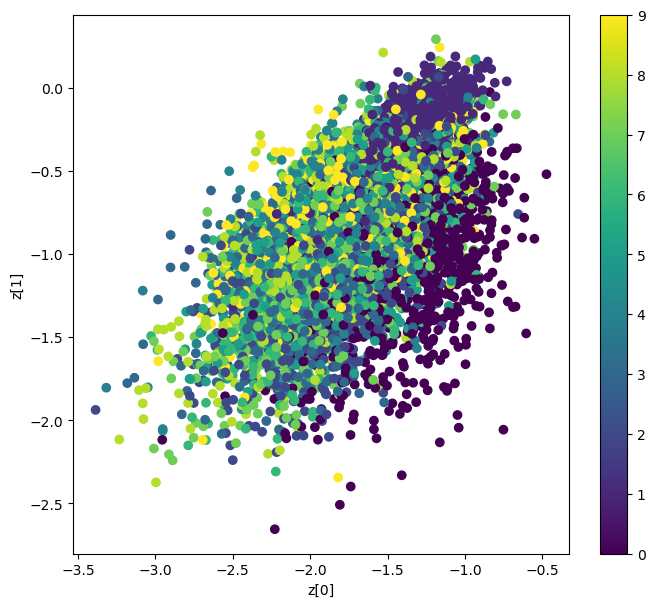

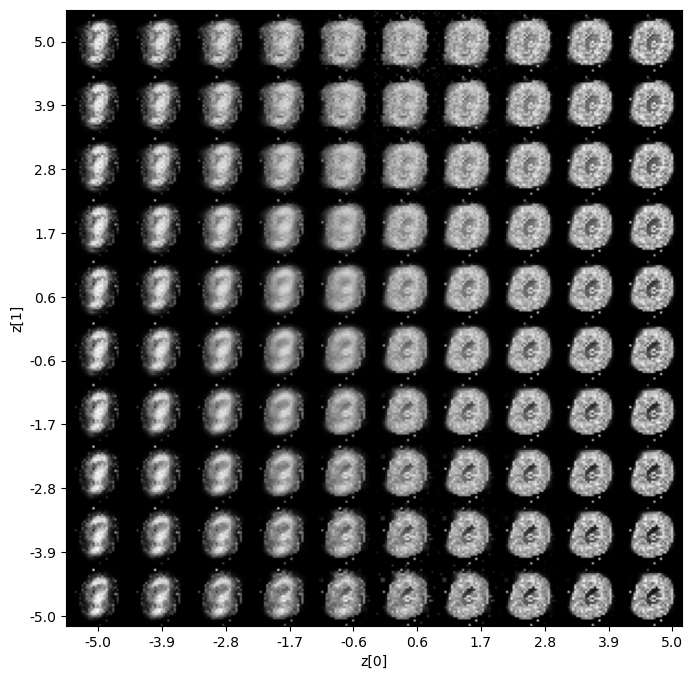

In [50]:
plot_results_var(models,
             data,
             batch_size=batch_size,
             model_name="vae_mlp", 
             lim=5)

Interesting results for just one epoch! As with the autoencoder above, you can modify the architecture of the VAE to try and produce better results, even adding convolutions.


### Exercise 6

Train VAE and AE for 10 epochs each, and plot the reconstruction MSE as a function of the number of epochs for each. Which one seems to have more potential to continuously learn as it is given more compute time? Is this surprising to you?


In [51]:
### BEGIN SOLUTION 
# Gather AE loss 
loss_ae = train_ae_epochs(10)

313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 1 is 391.27607211593386
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 2 is 278.2614104757971
313/313 [==============================] - 1s 3ms/step
Reconstruction loss after epoch 3 is 216.80263868013273
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 4 is 179.69759801907938
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 5 is 153.9958155875644
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 6 is 138.04486871679902
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 7 is 126.42982406338034
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 8 is 116.01012340390855
313/313 [==============================] - 1s 2ms/step
Reconstruction loss after epoch 9 is 111.90924041221834
313

In [52]:
# VAE model loss

In [53]:
vae_mse = []
for i in range(10):
    vae_model.fit(x_train_flat,
            epochs=1,
            batch_size=batch_size)
    decoded_images = vae_model.predict(x_test_flat)
    vae_mse.append(mse_reconstruction(decoded_images, x_test_flat))

313/313 [==============================] - 1s 2ms/step


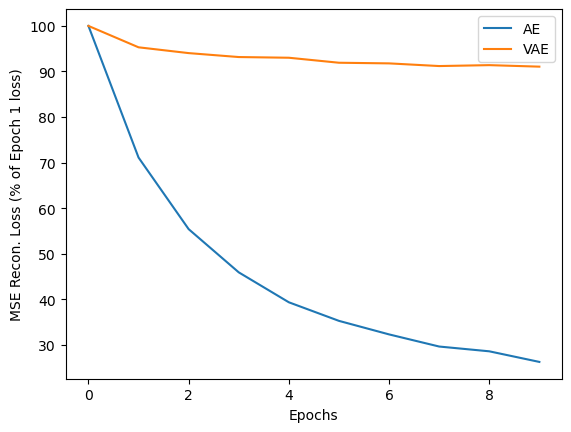

In [54]:
# Plot scaled losses
plt.plot(range(10), loss_ae/(.01*loss_ae[0]), label='AE')
plt.plot(range(10), vae_mse/(.01*vae_mse[0]), label='VAE')
plt.xlabel('Epochs')
plt.ylabel('MSE Recon. Loss (% of Epoch 1 loss)')
plt.legend()
### END SOLUTION 

---
### Machine Learning Foundation (C) 2020 IBM Corporation
